In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
import os, sys
from pathlib import Path

In [3]:
root = Path.cwd()
while not (root / "config" / "config.yaml").exists():
    if root == root.parent:
        raise FileNotFoundError("Root project tidak ditemukan")
    root = root.parent
os.chdir(root)
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

print(f"CWD: {os.getcwd()}")

CWD: d:\DS_Road\data-science-learning\04-project-portfolio-kaggle\4.1-end-to-end-project\po-late-delivery-risk


In [4]:
with open("config/config.yaml") as f:
    config = yaml.safe_load(f)

In [5]:
sns.set_theme(style="whitegrid", palette="muted")
figures_dir = Path("reports/figures")
figures_dir.mkdir(parents=True, exist_ok=True)

In [6]:
df_train = pd.read_csv(config['paths']['test_data'])
df_train.head()

,po_id,supplier_id,supplier_name,supplier_country,material_category,material_criticality,order_date,promised_delivery_date,quantity_ordered,unit_price_usd,...,shipping_method,distance_km,supplier_lead_time_avg_days,supplier_otd_rate_historical_pct,supplier_active_pos_count,is_peak_season,actual_delivery_date,delay_days,goods_receipt_status,is_late
0,PO-2025-002296,SUP-026,Supplier Generic 26,Indonesia,Packaging,Medium,2025-02-10,2025-02-15,663,NaN,...,Courier,317.0,2.0,83.4,9,0,2025-02-13,-2,Complete,0
1,PO-2025-002269,SUP-036,Supplier Generic 36,Indonesia,Raw Material,High,2025-03-21,2025-03-26,1082,17.64,...,Land,339.5,3.4,40.0,8,1,2025-03-24,-2,Complete,0
2,PO-2025-000784,SUP-043,Supplier Generic 43,Japan,Raw Material,Medium,2025-03-15,2025-04-10,340,10.61,...,Sea,5698.4,18.0,63.2,8,1,2025-04-09,-1,Complete,0
3,PO-2025-001576,SUP-017,PT Prima Rekayasa Komponen,Vietnam,Component,Medium,2025-05-31,2025-06-18,264,12.66,...,Air,2129.1,19.5,65.3,5,0,2025-06-15,-3,Complete,0
4,PO-2025-002233,SUP-027,Supplier Generic 27,China,Raw Material,Medium,2025-06-25,2025-07-20,1126,14.42,...,Sea,3460.4,20.3,50.7,6,0,2025-07-18,-2,Complete,0


In [9]:
df_train['order_date'] = pd.to_datetime(df_train['order_date'])

target = config['columns']['target']
num_cols = config['columns']['numerical_columns']
cat_cols = config['columns']['categorical_columns']

print(f"Kolom target: {target}")
print(f"Kolom numerik: {num_cols}")
print(f"Kolom kategorikal: {cat_cols}\n")

print(f"Shape train : {df_train.shape}")
print(f"Late rate   : {df_train[target].mean():.3f} ({df_train[target].mean()*100:.1f}%)")


Kolom target: is_late
Kolom numerik: ['quantity_ordered', 'unit_price_usd', 'order_value_usd', 'distance_km', 'supplier_lead_time_avg_days', 'supplier_otd_rate_historical_pct', 'supplier_active_pos_count']
Kolom kategorikal: ['supplier_country', 'material_category', 'material_criticality', 'payment_terms', 'shipping_method']

Shape train : (832, 22)
Late rate   : 0.218 (21.8%)


In [11]:
print("=== DTYPES ===")
print(df_train.dtypes)

print("\n=== MISSING VALUES ===")
missing = df_train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df_train) * 100).round(2)
print(pd.DataFrame({"count": missing, "pct": missing_pct}))

print("\n=== BASIC STATS (numerik) ===")
print(df_train[num_cols].describe().round(2))

=== DTYPES ===
po_id                                          str
supplier_id                                    str
supplier_name                                  str
supplier_country                               str
material_category                              str
material_criticality                           str
order_date                          datetime64[us]
promised_delivery_date                         str
quantity_ordered                             int64
unit_price_usd                             float64
order_value_usd                            float64
payment_terms                                  str
shipping_method                                str
distance_km                                float64
supplier_lead_time_avg_days                float64
supplier_otd_rate_historical_pct           float64
supplier_active_pos_count                    int64
is_peak_season                               int64
actual_delivery_date                           str
delay_days      

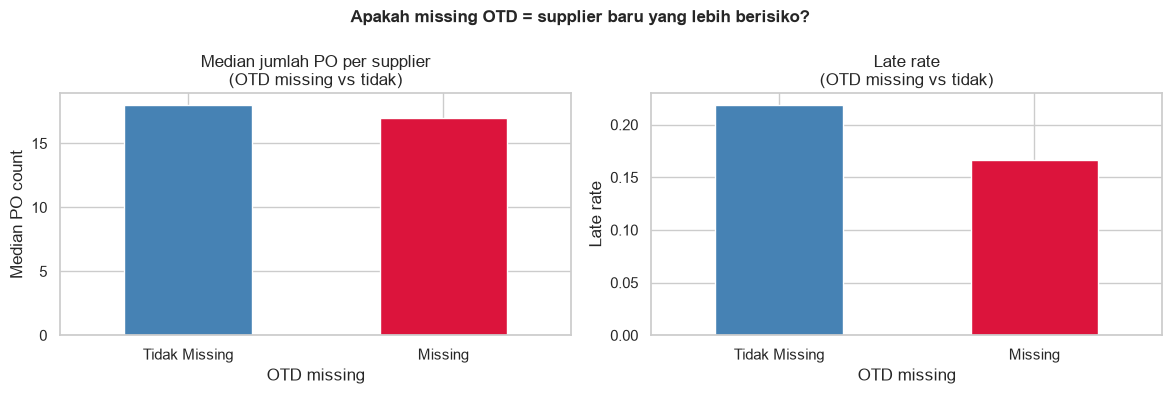


📌 INSIGHT:
Median PO count — tidak missing : 18
Median PO count — missing       : 17
Late rate — tidak missing        : 0.219
Late rate — missing              : 0.167
→ Catat insight ini untuk menentukan strategi imputasi di Pipeline nanti.


In [13]:
# ════════════════════════════════════════════════
# CELL 4 — Analisis Missing Value
# Pertanyaan: apakah missing bersifat acak atau informatif?
# ════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# missing supplier_otd_rate: apakah supplier baru (sedikit PO)?
po_count_per_supplier = df_train.groupby("supplier_id").size().rename("po_count")
df_train_m = df_train.merge(po_count_per_supplier, on="supplier_id")
df_train_m["otd_missing"] = df_train_m["supplier_otd_rate_historical_pct"].isna()

df_train_m.groupby("otd_missing")["po_count"].median().plot(
    kind="bar", ax=axes[0], color=["steelblue", "crimson"], edgecolor="white"
)
axes[0].set_title("Median jumlah PO per supplier\n(OTD missing vs tidak)")
axes[0].set_xlabel("OTD missing")
axes[0].set_ylabel("Median PO count")
axes[0].set_xticklabels(["Tidak Missing", "Missing"], rotation=0)

# late rate: missing OTD vs tidak
df_train_m.groupby("otd_missing")[target].mean().plot(
    kind="bar", ax=axes[1], color=["steelblue", "crimson"], edgecolor="white"
)
axes[1].set_title("Late rate\n(OTD missing vs tidak)")
axes[1].set_xlabel("OTD missing")
axes[1].set_ylabel("Late rate")
axes[1].set_xticklabels(["Tidak Missing", "Missing"], rotation=0)

plt.suptitle("Apakah missing OTD = supplier baru yang lebih berisiko?",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(figures_dir / "missing_otd_analysis.png", dpi=150)
plt.show()

# insight
print("\n📌 INSIGHT:")
print(f"Median PO count — tidak missing : {df_train_m[~df_train_m['otd_missing']]['po_count'].median():.0f}")
print(f"Median PO count — missing       : {df_train_m[df_train_m['otd_missing']]['po_count'].median():.0f}")
print(f"Late rate — tidak missing        : {df_train_m[~df_train_m['otd_missing']][target].mean():.3f}")
print(f"Late rate — missing              : {df_train_m[df_train_m['otd_missing']][target].mean():.3f}")
print("→ Catat insight ini untuk menentukan strategi imputasi di Pipeline nanti.")